# tmp — feb25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_vae['tbptt_steps'] = -1
cfg_vae['n_iters_inner'] = 1

# cfg_vae['fit_prior'] = False
cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 20.0
cfg_tr['epochs'] = 300

mod = IPVAE(ConfigPoisVAE(**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [4]:
mod.cfg.clamp_du, mod.cfg.clamp_u

(7.0, 8.0)

In [5]:
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")

vH16_t-16_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_14,23:58)

In [6]:
print(mod.cfg.sequences)

{0: range(0, 16)}

In [7]:
cm = f"reproduce-with-tbptt-option-disabled"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 269.862115: 100%|████| 300/300 [3:19:42<00:00, 39.94s/it]


epoch # 300, avg loss: 269.844871: 100%|████| 300/300 [3:13:58<00:00, 38.79s/it]


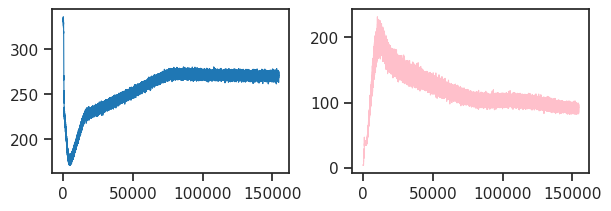

In [8]:
fig, axes = create_figure(1, 2)
axes[0].plot(list(tr.stats['loss'].values()), lw=0.8,)
axes[1].plot(list(tr.stats['grad'].values()), lw=0.8, color='pink');

In [9]:
u_min = np.asarray(tr.model.stats['u_min'])
u_max = np.asarray(tr.model.stats['u_max'])
du_min = np.asarray(tr.model.stats['du_min'])
du_max = np.asarray(tr.model.stats['du_max'])

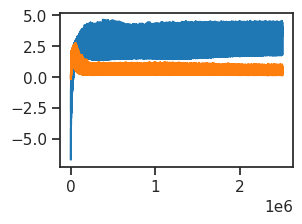

In [10]:
plt.plot(u_max);
plt.plot(du_max);

In [11]:
tr.model.cfg.clamp_u, tr.model.cfg.clamp_du

(8.0, 7.0)

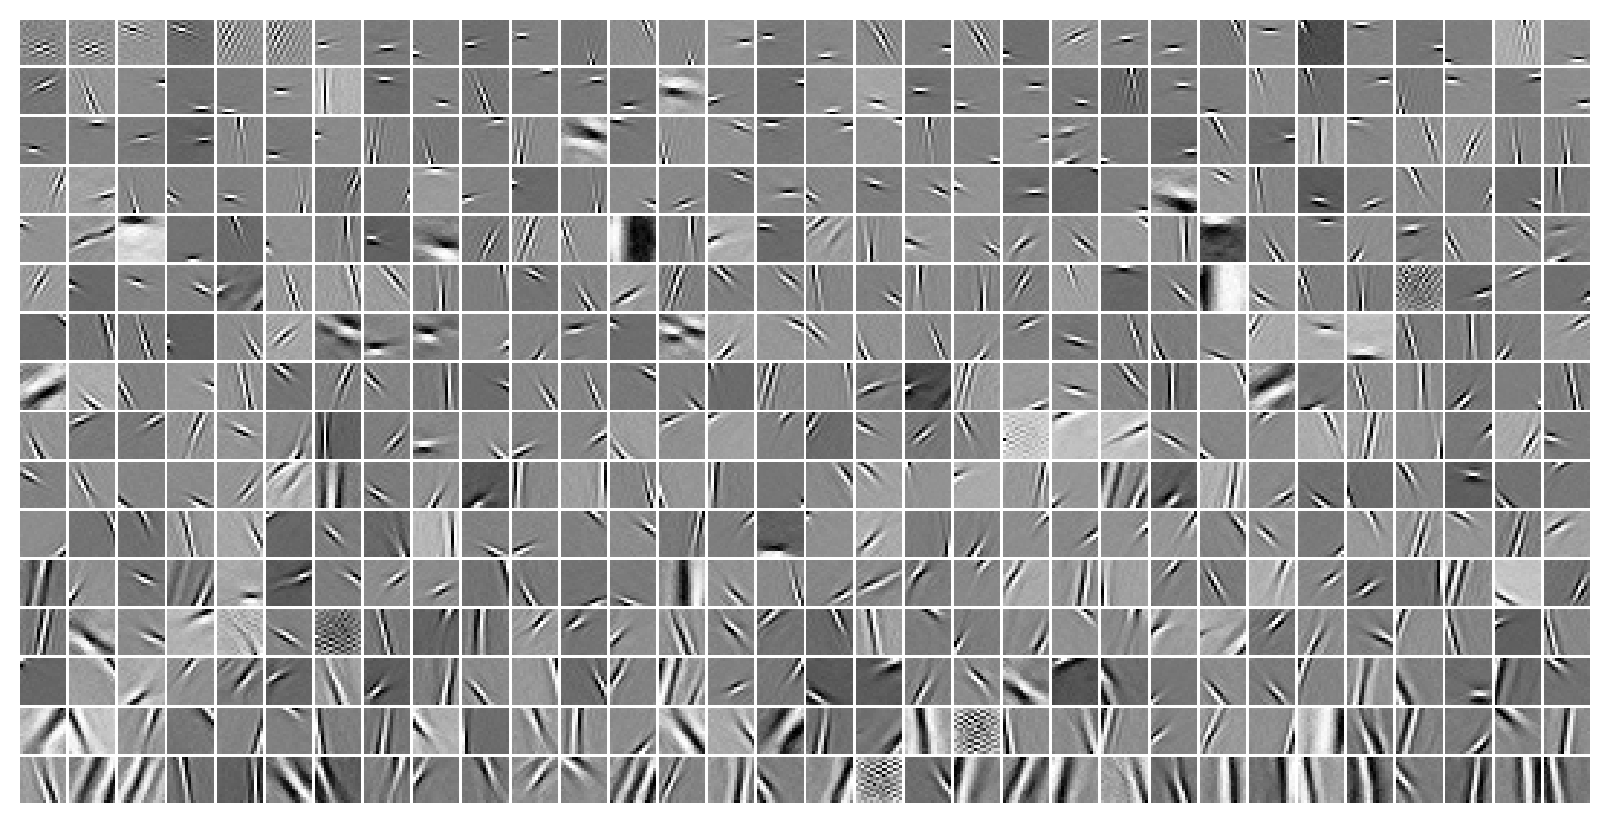

In [12]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

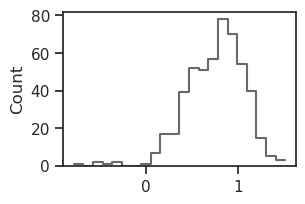

In [13]:
histplot(u0, color='dimgray');

100%|███████████████████████████████████| 2/2 [00:59<00:00, 29.65s/it]


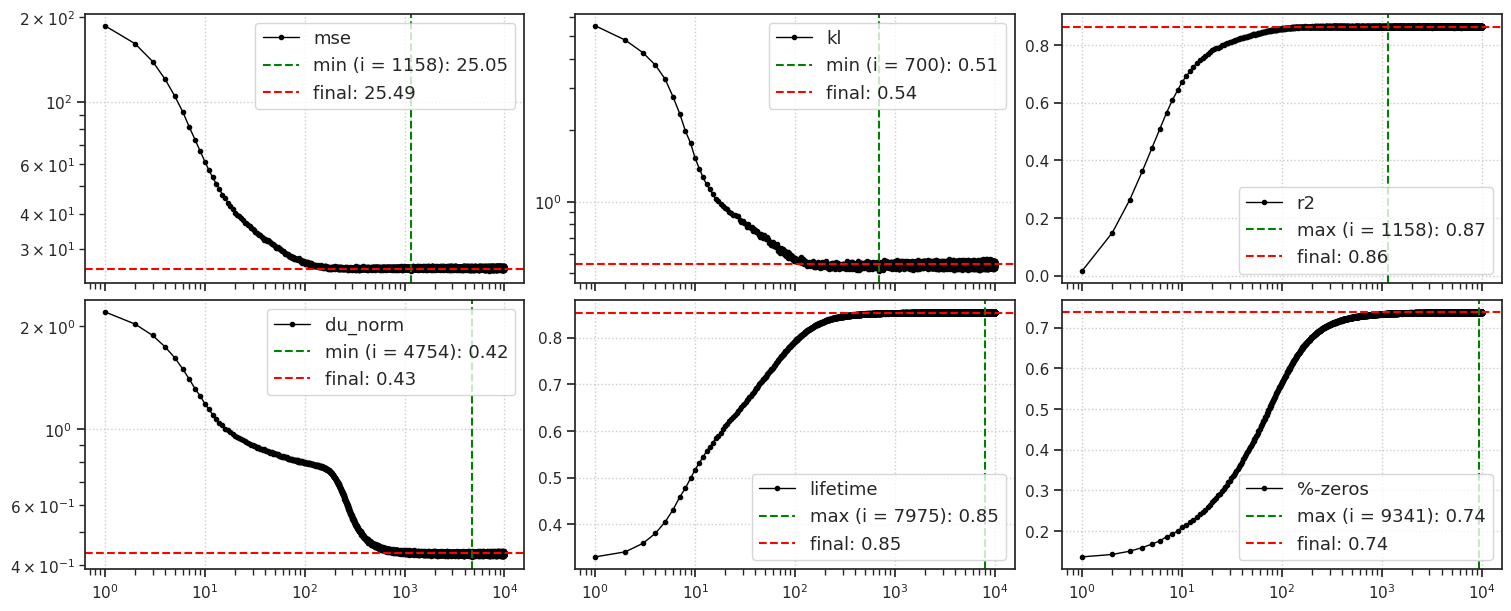

CPU times: user 1min 9s, sys: 5.93 s, total: 1min 15s
Wall time: 1min 15s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [15]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

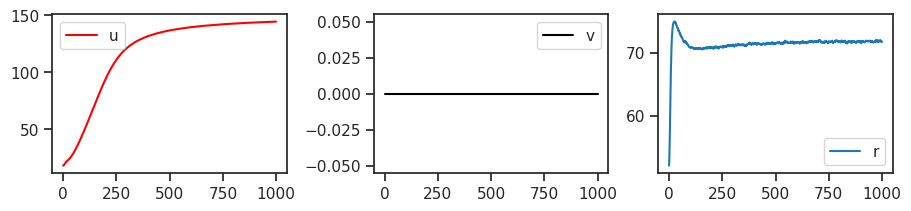

In [16]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

In [3]:
s = 'vH16_t-16_z-[512]_<grad|lin>/b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_13,09:32)'
tr, meta = load_model(s, False, device=device)

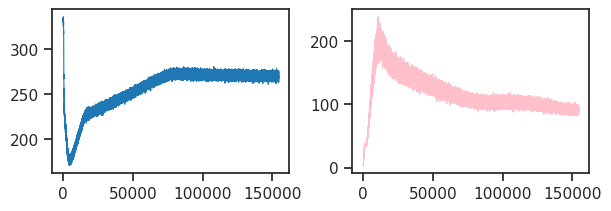

In [8]:
fig, axes = create_figure(1, 2)
axes[0].plot(list(tr.stats['loss'].keys()), list(tr.stats['loss'].values()), lw=0.8,)
axes[1].plot(list(tr.stats['grad'].keys()), list(tr.stats['grad'].values()), lw=0.8, color='pink');